error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

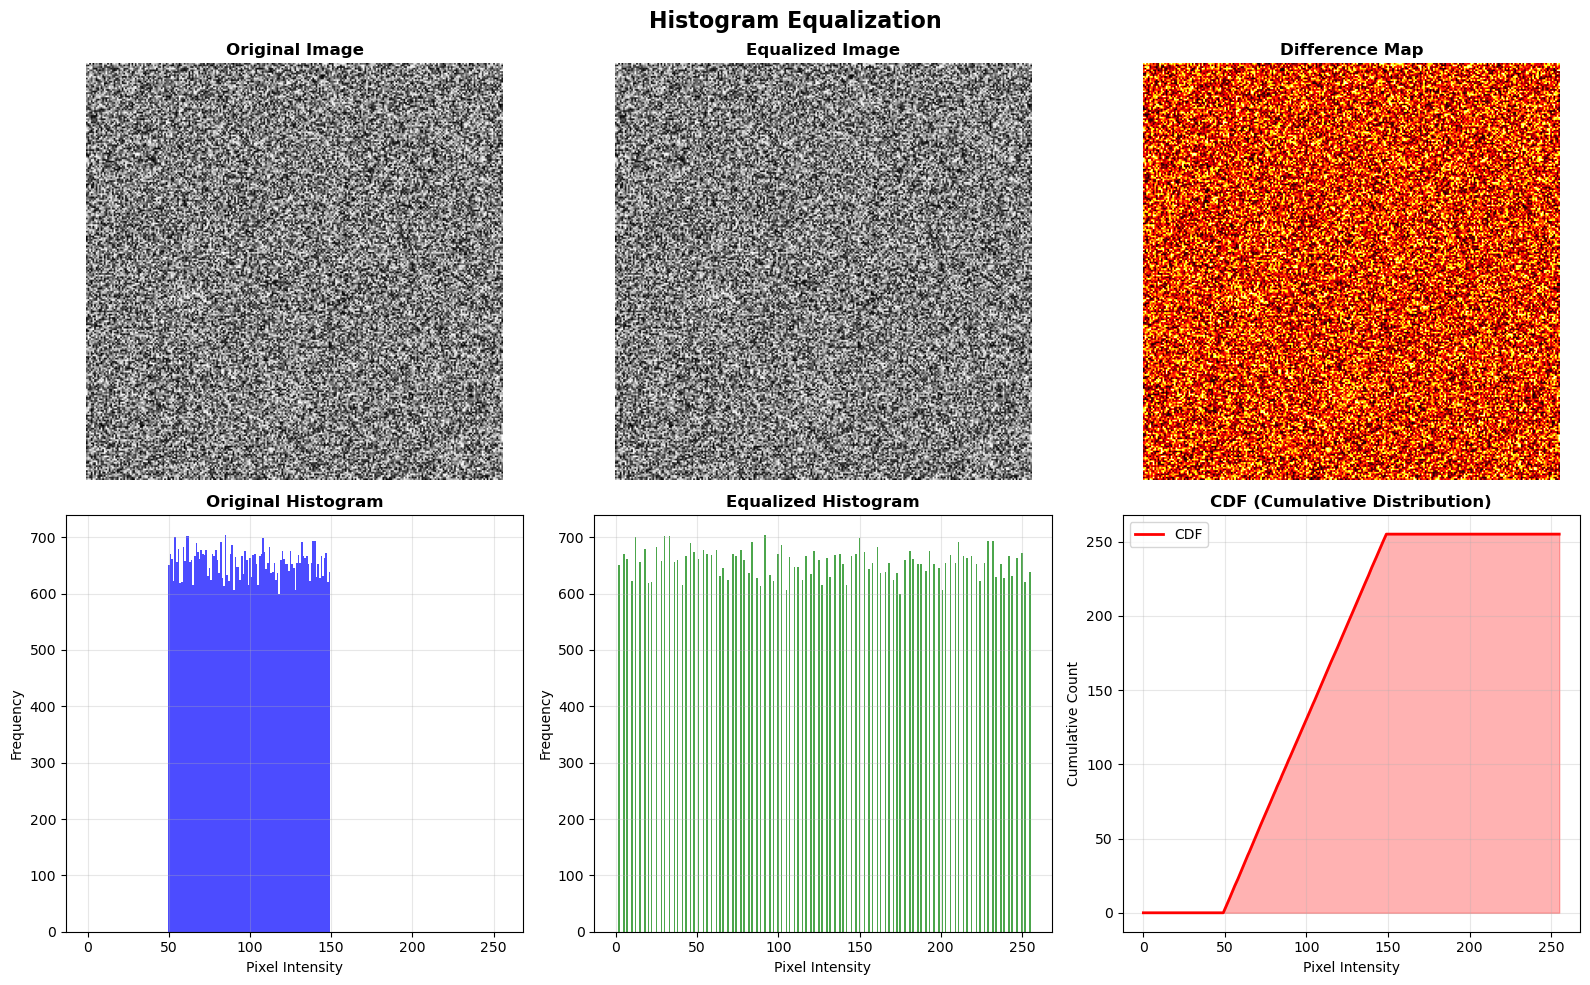


HISTOGRAM EQUALIZATION STATISTICS
Original Image:
  Shape: (256, 256)
  Min: 50, Max: 149, Mean: 99.37
  Std Dev: 28.90

Equalized Image:
  Shape: (256, 256)
  Min: 2, Max: 255, Mean: 128.30
  Std Dev: 73.59

Improvement:
  Mean Shift: 28.92
  Std Dev Increase: 44.70
✓ Histogram Equalization Complete!


In [2]:
%pip install -q pillow numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load or create sample image
image = None
if os.path.exists('image.jpg'):
    try:
        image = np.array(Image.open('image.jpg').convert('L'))
        print(f"✓ Image loaded successfully. Shape: {image.shape}")
    except Exception as e:
        print(f"Could not load image: {e}")

if image is None:
    # Create sample image with low contrast
    image = np.random.randint(50, 150, (256, 256), dtype=np.uint8)
    print("✓ Created a low-contrast sample image")

print(f"Image dtype: {image.dtype}, range: [{image.min()}, {image.max()}]")

# Function to compute histogram
def compute_histogram(image):
    """Compute histogram of an image"""
    hist = np.zeros(256)
    for pixel_value in image.flatten():
        hist[pixel_value] += 1
    return hist

# Function to perform histogram equalization
def histogram_equalization(image):
    """
    Perform histogram equalization on an image.
    Improves contrast by spreading out pixel intensities.
    """
    # Compute histogram
    hist = compute_histogram(image)
    
    # Compute CDF (Cumulative Distribution Function)
    cdf = np.cumsum(hist)
    
    # Normalize CDF to [0, 255]
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    
    # Apply mapping to original image
    equalized_image = cdf_normalized[image].astype(np.uint8)
    
    return equalized_image, hist, cdf_normalized

# Perform histogram equalization
equalized_image, original_hist, equalized_cdf = histogram_equalization(image)

# Compute histogram of equalized image
equalized_hist = compute_histogram(equalized_image)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Histogram Equalization', fontsize=16, fontweight='bold')

# Row 1: Images
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title('Equalized Image', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Difference visualization using PIL (no cv2 needed)
diff = np.abs(image.astype(int) - equalized_image.astype(int)).astype(np.uint8)
axes[0, 2].imshow(diff, cmap='hot')
axes[0, 2].set_title('Difference Map', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Histograms
axes[1, 0].bar(range(256), original_hist, color='blue', alpha=0.7, width=1.0)
axes[1, 0].set_title('Original Histogram', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].bar(range(256), equalized_hist, color='green', alpha=0.7, width=1.0)
axes[1, 1].set_title('Equalized Histogram', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

# CDF
axes[1, 2].plot(equalized_cdf, color='red', linewidth=2, label='CDF')
axes[1, 2].fill_between(range(256), equalized_cdf, alpha=0.3, color='red')
axes[1, 2].set_title('CDF (Cumulative Distribution)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Pixel Intensity')
axes[1, 2].set_ylabel('Cumulative Count')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('histogram_equalization_output.png', dpi=150, bbox_inches='tight')
print("✓ Plot saved as 'histogram_equalization_output.png'")
plt.show()

# Calculate and display statistics
print(f"\n{'='*60}")
print("HISTOGRAM EQUALIZATION STATISTICS")
print(f"{'='*60}")
print(f"Original Image:")
print(f"  Shape: {image.shape}")
print(f"  Min: {image.min()}, Max: {image.max()}, Mean: {image.mean():.2f}")
print(f"  Std Dev: {image.std():.2f}")
print(f"\nEqualized Image:")
print(f"  Shape: {equalized_image.shape}")
print(f"  Min: {equalized_image.min()}, Max: {equalized_image.max()}, Mean: {equalized_image.mean():.2f}")
print(f"  Std Dev: {equalized_image.std():.2f}")
print(f"\nImprovement:")
print(f"  Mean Shift: {equalized_image.mean() - image.mean():.2f}")
print(f"  Std Dev Increase: {equalized_image.std() - image.std():.2f}")
print(f"{'='*60}")
print("✓ Histogram Equalization Complete!")